<a href="https://colab.research.google.com/github/erknoztk/capstone/blob/master/cp2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd

df = pd.read_csv("cp2/DAYTON_hourly.csv")
df.head()

,Datetime,DAYTON_MW
0,2004-12-31 01:00:00,1596.0
1,2004-12-31 02:00:00,1517.0
2,2004-12-31 03:00:00,1486.0
3,2004-12-31 04:00:00,1469.0
4,2004-12-31 05:00:00,1472.0


In [16]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df = df.reset_index(drop=True)

In [17]:
features = ["DAYTON_MW"]
X = df[features].values

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
train_size = int(len(X_scaled) * 0.7)
val_size = int(len(X_scaled) * 0.15)

X_train = X_scaled[:train_size]
X_val = X_scaled[train_size:train_size + val_size]
X_test = X_scaled[train_size + val_size:]

In [20]:
import tensorflow as tf
from tensorflow import keras

input_dim = X_train.shape[1]

autoencoder = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")

In [21]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=False
)

Epoch 1/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0052 - val_loss: 1.1864e-06
Epoch 2/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 7.5844e-05 - val_loss: 2.4233e-05
Epoch 3/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.2026e-04 - val_loss: 6.6864e-06
Epoch 4/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 9.2606e-05 - val_loss: 3.0794e-07
Epoch 5/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.0302e-04 - val_loss: 1.2011e-05
Epoch 6/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 7.8052e-05 - val_loss: 1.5472e-07
Epoch 7/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 7.3740e-05 - val_loss: 3.5863e-06
Epoch 8/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 5.8489e-05 - val_loss: 4.8946e-06
Epoch 9/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 6.5576e-05 - val_loss: 4.8983e-07
Epoch 10/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.5003e-04 - val_loss: 7.1758e-07
Epoch 11/20
2653/2653 ━━━━━━━━━━━━━━━━━━━━

In [22]:
import numpy as np

X_val_pred = autoencoder.predict(X_val)

mse = np.mean(np.power(X_val - X_val_pred, 2), axis=1)

569/569 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [32]:
threshold = np.mean(mse) + 3*np.std(mse)
print("Threshold:", threshold)

Threshold: 4.065323145630348e-05


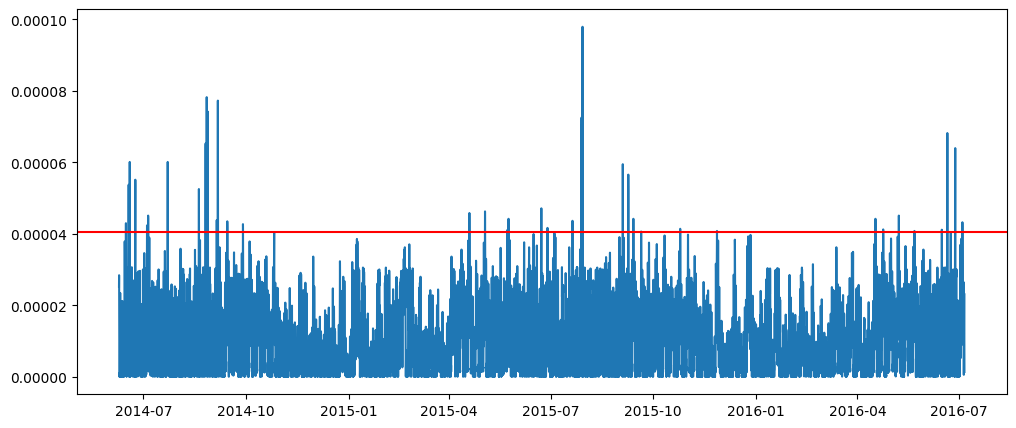

In [34]:
df["reconstruction_error"] = np.nan

df.iloc[train_size:train_size+val_size, df.columns.get_loc("reconstruction_error")] = mse

plt.figure(figsize=(12,5))
plt.plot(df["Datetime"], df["reconstruction_error"])
plt.axhline(threshold, color="red")
plt.show()

In [36]:
X_pred = autoencoder.predict(X_scaled)
all_mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

3790/3790 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [37]:
df["reconstruction_error"] = all_mse
df["anomaly"] = df["reconstruction_error"] > threshold

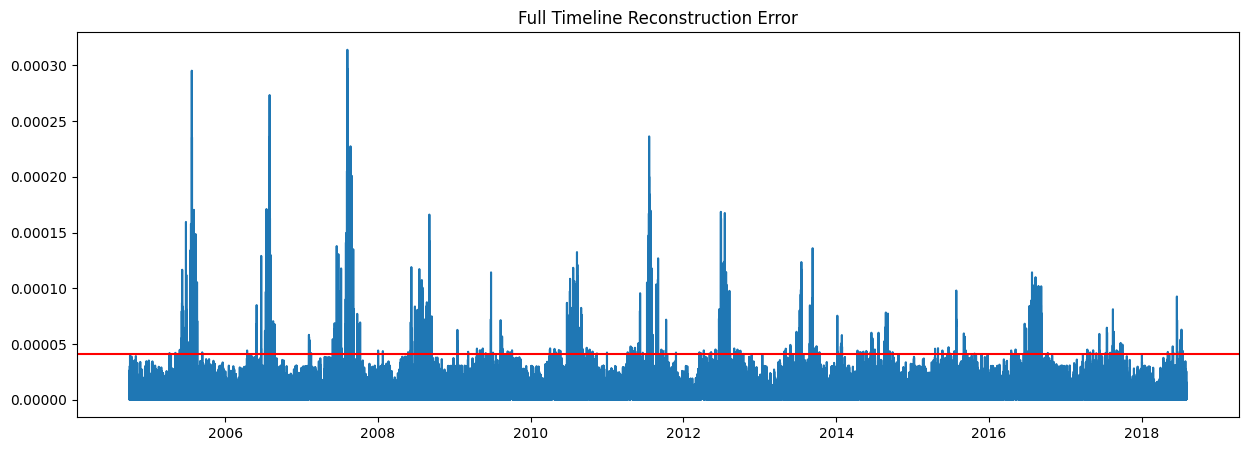

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df["Datetime"], df["reconstruction_error"])
plt.axhline(threshold, color="red")
plt.title("Full Timeline Reconstruction Error")
plt.show()

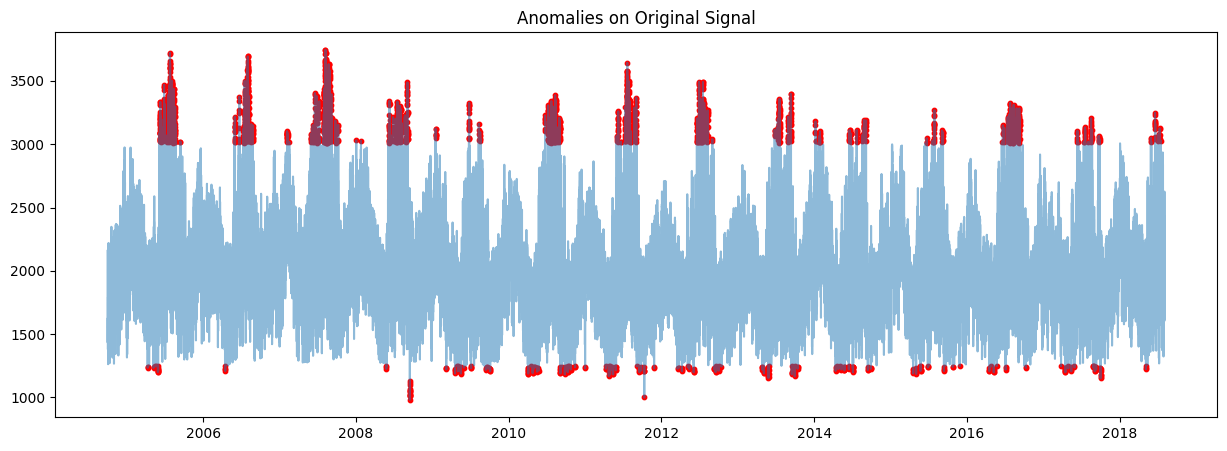

In [39]:
plt.figure(figsize=(15,5))

plt.plot(df["Datetime"], df["DAYTON_MW"], alpha=0.5)

plt.scatter(
    df[df["anomaly"]]["Datetime"],
    df[df["anomaly"]]["DAYTON_MW"],
    color="red",
    s=10
)

plt.title("Anomalies on Original Signal")
plt.show()